# ============================================
# Name: Chaitanya Panjare
# Name of the Industry: YBI Foundation
# Registration: 22017017
# Major Area: Data Science and Machine Learning
# ============================================

### Check GPU Availability
This cell imports TensorFlow and checks if a GPU is available for computation. It prints the list of detected GPU devices.

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Enable Mixed Precision & Check GPU
This cell enables mixed precision (float16) to speed up training and reduce memory usage on supported GPUs. It then checks and displays available GPU devices.

In [3]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Optimize for Ampere architecture (RTX 30 series)
mixed_precision.set_global_policy('mixed_float16')

print(tf.config.list_physical_devices('GPU'))

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3080 Laptop GPU, compute capability 8.6
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Download IAM Dataset
This cell downloads the IAM Handwriting dataset from a GitHub release if it is not already present in the local directory. It avoids re-downloading if the file exists.

In [5]:
import urllib.request
import os

url = "https://github.com/sayakpaul/Handwriting-Recognizer-in-Keras/releases/download/v1.0.0/IAM_Words.zip"
filename = "iam_dataset.zip"

if not os.path.exists(filename):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")
else:
    print("Dataset already exists.")

Download complete.


### Extract Dataset Files
This cell extracts the contents of the downloaded ZIP file into the current directory, making the dataset ready for use.

In [6]:
import zipfile

with zipfile.ZipFile("iam_dataset.zip", "r") as zip_ref:
    zip_ref.extractall(".")
print("Unzipping complete.")

Unzipping complete.


### Extract TAR Dataset
This cell checks if the `words.tgz` file is already extracted. If not, it extracts the compressed TAR file containing word images into the current directory.

In [7]:
import tarfile

if not os.path.exists("words.tgz"):
    # Adjusted path based on your notebook structure
    with tarfile.open("IAM_Words/words.tgz", "r:gz") as tar:
        tar.extractall(".")
    print("Extraction complete.")

Extraction complete.


### View Directory Contents
This cell lists the files and folders in the current directory and displays the first few items to verify dataset extraction.

In [8]:
import os
os.listdir()[:10]

['.ipynb_checkpoints',
 'a01',
 'a02',
 'a03',
 'a04',
 'a05',
 'a06',
 'b01',
 'b02',
 'b03']

### Verify Sample Image Path
This cell checks whether a specific image file exists in the dataset directory to confirm that the extraction was successful.

In [9]:
import os
print(os.path.exists("a01/a01-000u/a01-000u-00-00.png"))

True


### Prepare Dataset DataFrame
This cell reads the `words.txt` file, extracts valid image paths and corresponding text labels, filters out errors or corrupted images, and stores the cleaned data in a Pandas DataFrame.

In [35]:
import pandas as pd
import os

words_file = "IAM_Words/words.txt"
image_root = "." # Ensure this points to the correct root folder

data = []
with open(words_file) as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split(" ")
        if parts[1] == "err":
            continue

        word_id = parts[0]
        text = parts[-1]

        folder1 = word_id.split("-")[0]
        folder2 = "-".join(word_id.split("-")[:2])
        img_path = os.path.join(image_root, folder1, folder2, word_id + ".png")

        # CRITICAL UPDATE: Check if it exists AND is larger than 0 bytes
        if os.path.exists(img_path) and os.path.getsize(img_path) > 0:
            data.append([img_path, text])
        else:
            # Optional: Uncomment the print statement below if you want to see which files are broken
            # print(f"Skipping corrupted/missing file: {img_path}")
            pass

df = pd.DataFrame(data, columns=["image", "text"])
print("Verified valid images found on disk:", len(df))

Verified valid images found on disk: 96454


In [36]:
df.head()

,image,text
0,.\a01\a01-000u\a01-000u-00-00.png,A
1,.\a01\a01-000u\a01-000u-00-01.png,MOVE
2,.\a01\a01-000u\a01-000u-00-02.png,to
3,.\a01\a01-000u\a01-000u-00-03.png,stop
4,.\a01\a01-000u\a01-000u-00-04.png,Mr.


### Display Sample Image
This cell loads a sample image from the dataset using OpenCV and displays it with its corresponding text label using Matplotlib.

(-0.5, 26.5, 50.5, -0.5)

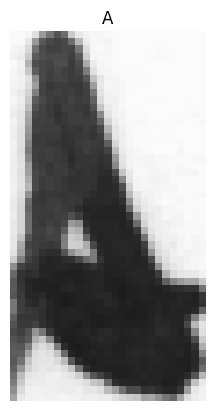

In [37]:
import cv2
import matplotlib.pyplot as plt

img_path = df["image"][0]

img = cv2.imread(img_path)

plt.imshow(img, cmap="gray")
plt.title(df["text"][0])
plt.axis("off")

### Build Character Vocabulary
This cell extracts all unique characters from the text labels, creates mappings from characters to numbers and vice versa, and calculates the total vocabulary size.

In [32]:
characters = set()

for t in df["text"]:
    characters.update(list(t))

characters = sorted(list(characters))

char_to_num = {c:i+1 for i,c in enumerate(characters)}
num_to_char = {i:c for c,i in char_to_num.items()}

vocab_size = len(characters) + 1

print("Vocabulary size:", vocab_size)

Vocabulary size: 79


### Define Image & Label Parameters
This cell sets constants for image width, image height, and maximum label length to standardize input dimensions for the model.

In [38]:
IMG_WIDTH = 128
IMG_HEIGHT = 32
MAX_LABEL_LEN = 32

### Create Efficient Data Pipeline
 Encoding text labels into numeric format, preprocesses images (resize, normalize), and builds an optimized TensorFlow dataset pipeline with batching, shuffling, caching, and prefetching for faster training.

In [39]:
import tensorflow as tf
import numpy as np

# 1. Pre-encode labels
encoded_labels = []
for t in df["text"].values:
    label = [char_to_num[c] for c in str(t)]
    label += [0] * (MAX_LABEL_LEN - len(label))
    encoded_labels.append(label)

encoded_labels = np.array(encoded_labels, dtype=np.int32)

# 2. Native preprocessing
def load_and_preprocess(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1) 
    img = tf.image.resize(img, [32, 128])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# 3. Create dataset
dataset = tf.data.Dataset.from_tensor_slices((df["image"].values, encoded_labels))

dataset = (
    dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()         
    .shuffle(10000)
    .batch(64)       
    .prefetch(tf.data.AUTOTUNE)
)

# 4. Final verification test
for img, label in dataset.take(1):
    print("Batch Success! The pipeline is clean.")
    print("Image Batch Shape:", img.shape)
    print("Label Batch Shape:", label.shape)

Batch Success! The pipeline is clean.
Image Batch Shape: (64, 32, 128, 1)
Label Batch Shape: (64, 32)


### Check for Missing Image Files
This cell scans all image paths in the dataset and identifies any missing or broken file paths, helping ensure data integrity before training.

In [40]:
bad_paths = []

for path in df["image"]:
    if not os.path.exists(path):
        bad_paths.append(path)

print("Broken paths:", len(bad_paths))
print(bad_paths[:5])

Broken paths: 0
[]


### Build CNN + BiLSTM Model
This cell defines a deep learning model using CNN layers for feature extraction, reshapes the output for sequence learning, applies BiLSTM layers for capturing text patterns, and outputs character probabilities using a softmax layer.

In [41]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

input_img = layers.Input(shape=(32,128,1))

# CNN feature extractor
x = layers.Conv2D(64,3,padding="same",activation="relu")(input_img)
x = layers.MaxPool2D((2,2))(x)

x = layers.Conv2D(128,3,padding="same",activation="relu")(x)
x = layers.MaxPool2D((2,2))(x)

x = layers.Conv2D(256,3,padding="same",activation="relu")(x)

# reshape for sequence model
shape = x.shape

x = layers.Reshape((shape[2], shape[1]*shape[3]))(x)

# BiLSTM layers
x = layers.Bidirectional(
    layers.LSTM(256, return_sequences=True)
)(x)

x = layers.Bidirectional(
    layers.LSTM(256, return_sequences=True)
)(x)

# output layer
# Change ONLY the last layer in your model definition:
output = layers.Dense(vocab_size + 1, activation="softmax", dtype='float32')(x)

model = Model(inputs=input_img, outputs=output)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 128, 1)]      0         
                                                                 
 conv2d (Conv2D)             (None, 32, 128, 64)       640       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 64, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 64, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 32, 128)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 32, 256)        295168

### Define CTC Loss Function
This cell defines a custom CTC (Connectionist Temporal Classification) loss function that computes sequence alignment loss between predicted outputs and true labels, handling variable-length sequences without explicit alignment.

In [42]:
def ctc_loss(y_true, y_pred):

    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")

    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")

    label_length = tf.math.count_nonzero(y_true, axis=1)

    input_length = input_length * tf.ones(
        shape=(batch_len,1),
        dtype="int64"
    )

    label_length = tf.expand_dims(label_length,1)

    loss = tf.keras.backend.ctc_batch_cost(
        y_true,
        y_pred,
        input_length,
        label_length
    )

    return loss

### Compile the Model
This cell compiles the model using the Adam optimizer and the custom CTC loss function, preparing it for training.

In [43]:
model.compile(
    optimizer="adam",
    loss=ctc_loss
)

### Train Model with Early Stopping
This cell trains the model on the dataset for multiple epochs while using early stopping to prevent overfitting and restore the best-performing weights.

In [44]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="loss", 
    patience=5, 
    restore_best_weights=True
)

model.fit(
    dataset,
    epochs=50,
    callbacks=[early_stopping]
)

Epoch 1/50
1508/1508 [==============================] - 147s 88ms/step - loss: 11.8396
Epoch 2/50
1508/1508 [==============================] - 76s 50ms/step - loss: 7.4831
Epoch 3/50
1508/1508 [==============================] - 77s 51ms/step - loss: 5.6069
Epoch 4/50
1508/1508 [==============================] - 81s 54ms/step - loss: 4.4057
Epoch 5/50
1508/1508 [==============================] - 79s 53ms/step - loss: 3.5274
Epoch 6/50
1508/1508 [==============================] - 79s 52ms/step - loss: 2.7910
Epoch 7/50
1508/1508 [==============================] - 80s 53ms/step - loss: 2.1795
Epoch 8/50
1508/1508 [==============================] - 76s 51ms/step - loss: 1.6316
Epoch 9/50
1508/1508 [==============================] - 71s 47ms/step - loss: 1.2332
Epoch 10/50
1508/1508 [==============================] - 72s 48ms/step - loss: 0.9272
Epoch 11/50
1508/1508 [==============================] - 71s 47ms/step - loss: 0.7228
Epoch 12/50
1508/1508 [==============================] - 71s 

### Saving the Model 

In [45]:
model.save("htr_crnn_model.h5")

### Decode & Visualize Predictions
This cell decodes the model’s output using CTC decoding to convert predictions into readable text, then displays sample images with their predicted labels for evaluation.

2/2 [==============================] - 1s 17ms/step


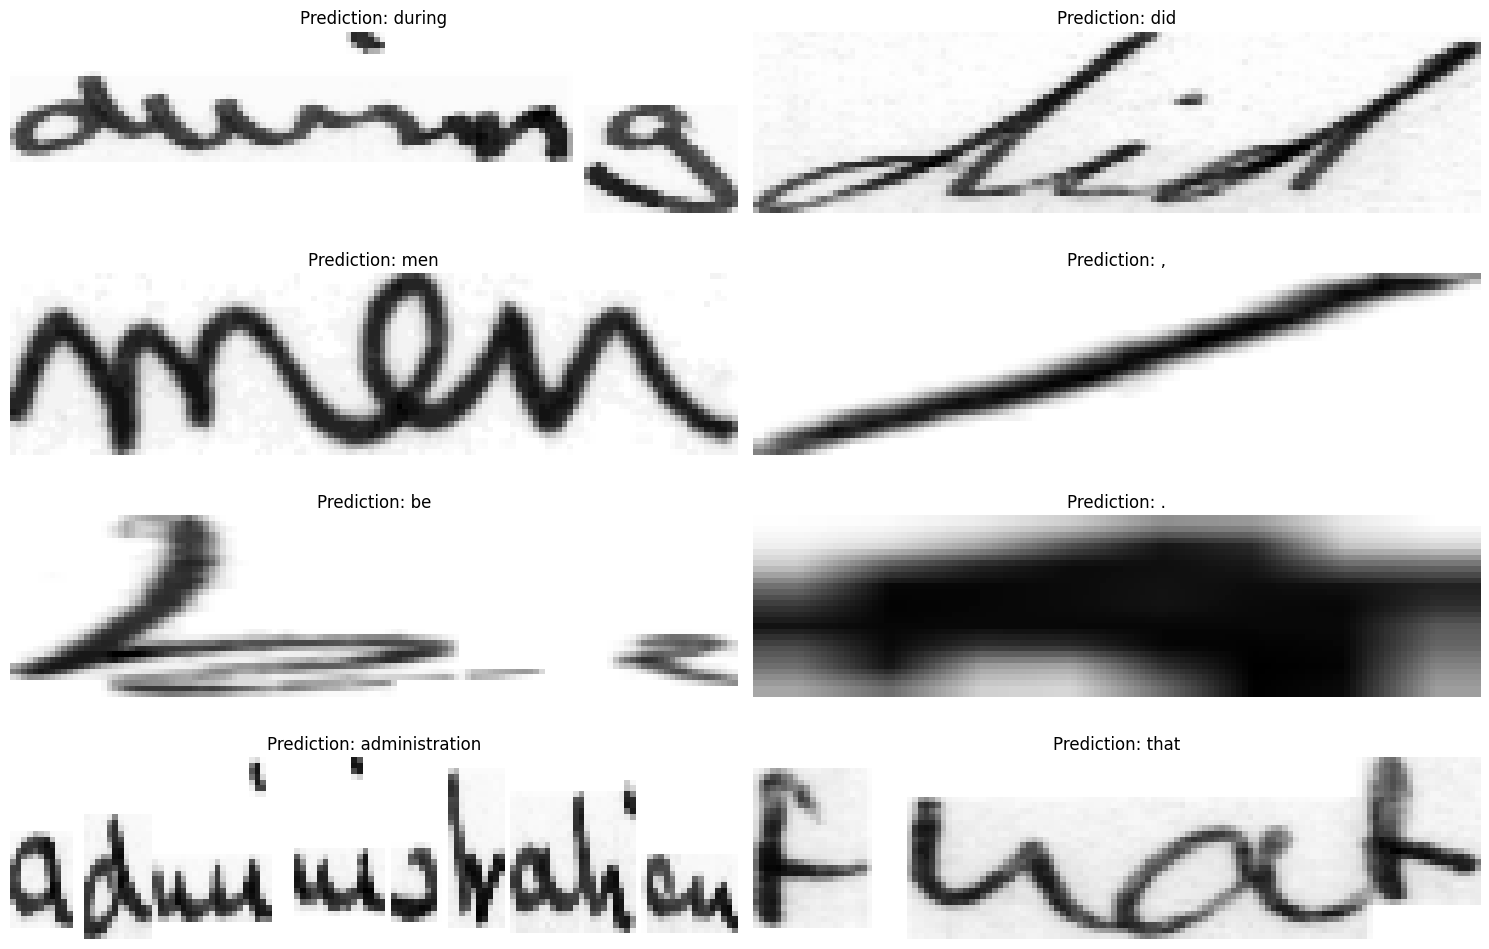

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CTC Decoding Function
def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    
    # greedy=True means we take the highest probability character at each step
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]
    
    # Convert the numerical predictions back to text
    output_text = []
    for res in results:
        # Ignore the -1 padding tokens
        chars = [num_to_char[int(c)] for c in res if int(c) != -1]
        output_text.append("".join(chars))
    return output_text

# 2. Test on a batch from your dataset
for batch_images, batch_labels in dataset.take(1):
    # Get the model's predictions
    preds = model.predict(batch_images)
    
    # Decode the predictions
    pred_texts = decode_batch_predictions(preds)
    
    # 3. Plot the first 8 images and their predicted text
    _, ax = plt.subplots(4, 2, figsize=(15, 10))
    for i in range(8):
        img = (batch_images[i] * 255).numpy().astype(np.uint8)
        
        # Determine the subplot position
        row = i // 2
        col = i % 2
        
        ax[row, col].imshow(img[:, :, 0], cmap="gray")
        ax[row, col].set_title(f"Prediction: {pred_texts[i]}")
        ax[row, col].axis("off")
        
    plt.tight_layout()
    plt.show()

### Compare True vs Predicted Text
This cell decodes both the model predictions and actual labels into readable text, then visualizes sample images with their true and predicted outputs for performance comparison.

2/2 [==============================] - 0s 19ms/step


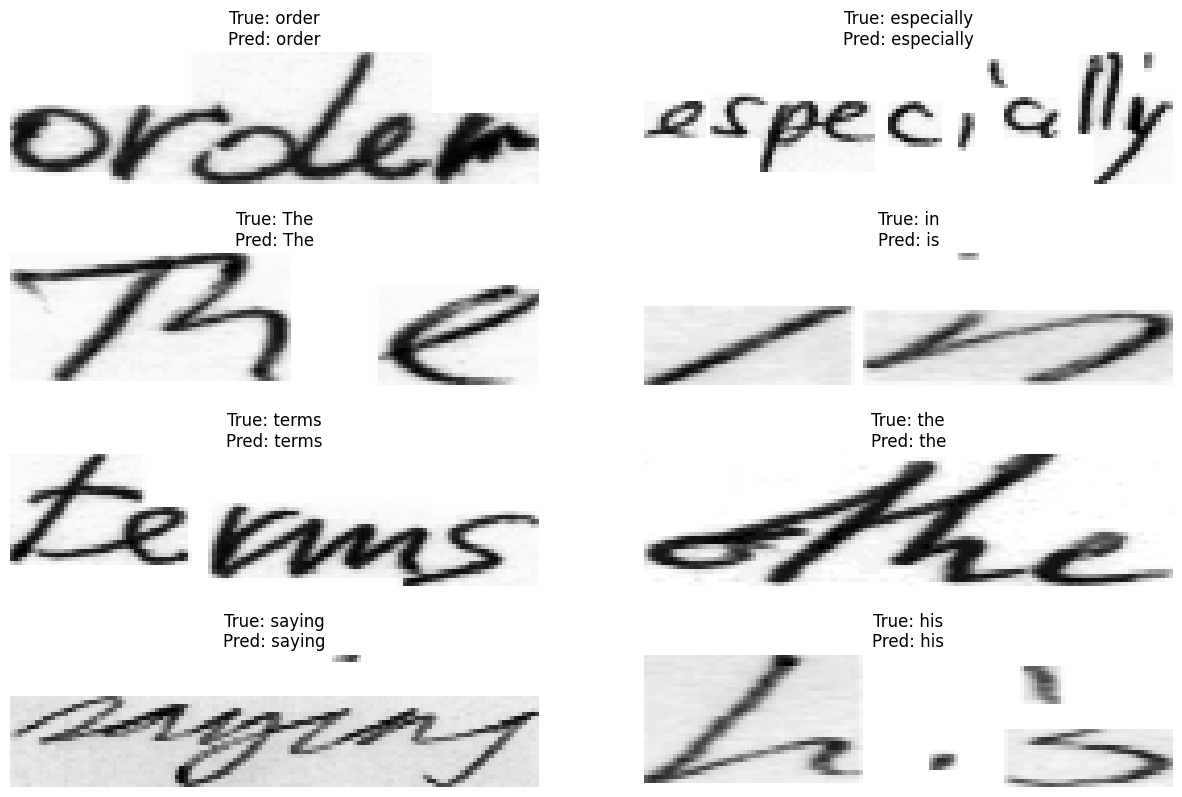

In [48]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    results = tf.keras.backend.ctc_decode(
        pred,
        input_length=input_len,
        greedy=True
    )[0][0]

    output_text = []
    for res in results:
        chars = [num_to_char[int(c)] for c in res if int(c) != -1]
        output_text.append("".join(chars))

    return output_text


# Function to convert label numbers → text
def decode_label(label):
    chars = [num_to_char[int(c)] for c in label if int(c) != 0]
    return "".join(chars)


for batch_images, batch_labels in dataset.take(1):

    preds = model.predict(batch_images)
    pred_texts = decode_batch_predictions(preds)

    true_texts = [decode_label(label.numpy()) for label in batch_labels]

    _, ax = plt.subplots(4,2,figsize=(15,10))

    for i in range(8):

        img = (batch_images[i]*255).numpy().astype("uint8")

        row = i//2
        col = i%2

        ax[row,col].imshow(img.squeeze(), cmap="gray")

        ax[row,col].set_title(
            f"True: {true_texts[i]}\nPred: {pred_texts[i]}"
        )

        ax[row,col].axis("off")

    plt.show()

### Calculate Character-Level Accuracy
This cell evaluates the model by comparing predicted text with true labels, computing character-level accuracy over multiple batches to measure performance.

In [49]:
from tqdm import tqdm

total_chars = 0
correct_chars = 0

for batch_images, batch_labels in tqdm(dataset.take(200)):

    preds = model.predict(batch_images)
    pred_texts = decode_batch_predictions(preds)

    true_texts = [
        "".join([num_to_char[int(c)] for c in label.numpy() if int(c)!=0])
        for label in batch_labels
    ]

    for t,p in zip(true_texts,pred_texts):

        length = min(len(t),len(p))

        for i in range(length):
            if t[i]==p[i]:
                correct_chars += 1

        total_chars += len(t)

accuracy = correct_chars / total_chars

print("Character Accuracy:", accuracy)

  0%|          | 0/200 [00:00<?, ?it/s]

2/2 [==============================] - 0s 18ms/step


  0%|          | 1/200 [00:00<02:38,  1.25it/s]

2/2 [==============================] - 0s 9ms/step


  1%|          | 2/200 [00:01<02:37,  1.26it/s]

...

2/2 [==============================] - 0s 16ms/step


100%|█████████▉| 199/200 [02:37<00:00,  1.30it/s]

2/2 [==============================] - 0s 11ms/step


100%|██████████| 200/200 [02:38<00:00,  1.26it/s]

Character Accuracy: 0.9594030583613917


### Predict Text from Image
This cell defines a function that preprocesses a single input image, runs it through the trained model, and decodes the prediction using CTC (beam search) to generate readable text.

In [50]:
import cv2
import numpy as np
import tensorflow as tf

def predict_text(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img,(128,32))

    img = img/255.0

    img = np.expand_dims(img,-1)

    img = np.expand_dims(img,0)

    pred = model.predict(img)

    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    decoded = tf.keras.backend.ctc_decode(
        pred,
        input_length=input_len,
        greedy=False,
        beam_width=10
    )[0][0]

    text = ""

    for c in decoded[0]:
        if int(c) != -1:
            text += num_to_char[int(c)]

    return text

### Test Model on Custom Image
This cell uses the prediction function to recognize and output text from a custom input image.

In [ ]:
predict_text("ripe.png")

1/1 [==============================] - 1s 922ms/step


'ripe'

In [52]:
predict_text("theimage.png")

1/1 [==============================] - 0s 32ms/step


'The'

In [ ]:
predict_text("hedor.png")

1/1 [==============================] - 0s 22ms/step


'hedor'

In [55]:
predict_text("Screenshot 2026-03-10 034517.png")

1/1 [==============================] - 0s 26ms/step


'vigine'

### Calculate Word-Level Accuracy
This cell evaluates the model by comparing complete predicted words with true labels, computing word-level accuracy over multiple batches.

In [56]:
from tqdm import tqdm

total_words = 0
correct_words = 0

for batch_images, batch_labels in tqdm(dataset.take(200)):

    preds = model.predict(batch_images)

    pred_texts = decode_batch_predictions(preds)

    true_texts = [
        "".join([num_to_char[int(c)] for c in label.numpy() if int(c) != 0])
        for label in batch_labels
    ]

    for true, pred in zip(true_texts, pred_texts):

        if true == pred:
            correct_words += 1

        total_words += 1


word_accuracy = correct_words / total_words

print("Word Accuracy:", word_accuracy)

  0%|          | 0/200 [00:00<?, ?it/s]

2/2 [==============================] - 0s 18ms/step


  0%|          | 1/200 [00:00<02:35,  1.28it/s]

2/2 [==============================] - 0s 21ms/step


  1%|          | 2/200 [00:01<02:33,  1.29it/s]

...

2/2 [==============================] - 0s 13ms/step


100%|█████████▉| 199/200 [02:34<00:00,  1.28it/s]

2/2 [==============================] - 0s 12ms/step


100%|██████████| 200/200 [02:35<00:00,  1.29it/s]

Word Accuracy: 0.92640625


### Model Performance Summary

- **Character-Level Accuracy:** The model achieved an outstanding **95.94%** character accuracy.  
- **Word-Level Accuracy:** The model reached a strong **92.64%** accuracy on full word predictions.  
- **Loss Convergence:** Training loss significantly reduced from **11.83 (Epoch 1)** to approximately **0.16**, indicating effective learning.